# FlashAttention-1 Benchmark: Standard vs. Tiling Simulation vs. Native GPU

This notebook benchmarks three attention implementations:
1. **Standard Attention**: A naive implementation materializing the $N \times N$ matrix in global memory (HBM).
2. **FlashAttention-1 Simulation**: A pure Python/PyTorch block-by-block tiling simulation (Algorithm 1) to verify mathematical equivalence.
3. **Native FlashAttention**: A high-performance CUDA implementation calling PyTorch's native `scaled_dot_product_attention` on GPU.

### The Library vs. Desk Analogy
- **HBM (High Bandwidth Memory)** is like the **Library Archive** (huge capacity but slow to access/walk to).
- **SRAM (On-Chip Cache)** is like your **Study Desk** (tiny capacity but right in front of you, accessible instantly).
- **Standard Attention** writes/reads intermediate giant drafts to the Library Archive constantly, slowing down due to memory latency.
- **FlashAttention (Tiling)** brings small blocks of keys/values to the study desk, computes running scaling statistics (online softmax) directly on the desk, and only writes the final output summary back to the library once at the end.

In [6]:
import math
import time
import torch
import torch.nn as nn

print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")

PyTorch Version: 2.10.0+cu128
CUDA Available: True
GPU Device: Tesla T4


## 1. Standard Self-Attention Implementation

In [7]:
def standard_attention(Q, K, V):
    """
    Standard self-attention: computes the full N x N matrix in global memory (HBM).
    Shape: Q, K, V are (B, H, N, d_k)
    """
    d_k = Q.shape[-1]
    # Q @ K^T / sqrt(d_k)
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)  # (B, H, N, N)
    attn_weights = torch.softmax(scores, dim=-1)                   # (B, H, N, N)
    output = torch.matmul(attn_weights, V)                          # (B, H, N, d_k)
    return output, attn_weights

## 2. FlashAttention-1 Simulation (Algorithm 1 Tiling)

In [8]:
def flash_attention_v1_sim(Q, K, V, B_r=64, B_c=64):
    """
    Python/PyTorch simulation of the FlashAttention-1 tiling algorithm (Algorithm 1).
    Computes exact attention block-by-block without materializing the N x N attention weights.
    Shape: Q, K, V are (B, H, N, d_k)
    """
    B, H, N, d = Q.shape
    d_k = d
    O = torch.zeros_like(Q)
    
    # Loop over batches and heads
    for b in range(B):
        for h in range(H):
            Q_bh = Q[b, h]  # (N, d)
            K_bh = K[b, h]  # (N, d)
            V_bh = V[b, h]  # (N, d)
            
            # Initialize scaling statistics in global memory (HBM)
            O_bh = torch.zeros((N, d), device=Q.device, dtype=Q.dtype)
            m_bh = torch.full((N, 1), float('-inf'), device=Q.device, dtype=Q.dtype)  # running max
            l_bh = torch.zeros((N, 1), device=Q.device, dtype=Q.dtype)                 # running sum of exps
            
            Tr = math.ceil(N / B_r)
            Tc = math.ceil(N / B_c)
            
            # Outer Loop: Load blocks of K, V into fast SRAM-like buffers
            for j in range(Tc):
                start_c = j * B_c
                end_c = min(start_c + B_c, N)
                
                K_j = K_bh[start_c:end_c, :]  # (B_c, d)
                V_j = V_bh[start_c:end_c, :]  # (B_c, d)
                
                # Inner Loop: Load blocks of Q, O, m, l
                for i in range(Tr):
                    start_r = i * B_r
                    end_r = min(start_r + B_r, N)
                    
                    Q_i = Q_bh[start_r:end_r, :]  # (B_r, d)
                    O_i = O_bh[start_r:end_r, :]  # (B_r, d)
                    m_i = m_bh[start_r:end_r, :]  # (B_r, 1)
                    l_i = l_bh[start_r:end_r, :]  # (B_r, 1)
                    
                    # --- SRAM Calculations ---
                    # Compute scores block: S_ij = (Q_i @ K_j^T) / sqrt(d_k)
                    S_ij = torch.matmul(Q_i, K_j.transpose(-2, -1)) / math.sqrt(d_k)  # (B_r, B_c)
                    
                    # Local max: tilde_m_ij
                    tilde_m_ij, _ = torch.max(S_ij, dim=-1, keepdim=True)  # (B_r, 1)
                    
                    # Local exps: tilde_P_ij = exp(S_ij - tilde_m_ij)
                    tilde_P_ij = torch.exp(S_ij - tilde_m_ij)  # (B_r, B_c)
                    
                    # Local sum of exps: tilde_l_ij
                    tilde_l_ij = torch.sum(tilde_P_ij, dim=-1, keepdim=True)  # (B_r, 1)
                    
                    # --- Online Update Statistics ---
                    m_i_new = torch.max(m_i, tilde_m_ij)  # (B_r, 1)
                    
                    # Rescaling coefficients
                    alpha = torch.exp(m_i - m_i_new)  # (B_r, 1)
                    beta = torch.exp(tilde_m_ij - m_i_new)  # (B_r, 1)
                    
                    l_i_new = alpha * l_i + beta * tilde_l_ij  # (B_r, 1)
                    
                    # Update outputs: O_i = (l_i * alpha * O_i + beta * tilde_P_ij @ V_j) / l_i_new
                    O_i_new = (l_i * alpha * O_i + beta * torch.matmul(tilde_P_ij, V_j)) / l_i_new
                    
                    # Save back to HBM
                    O_bh[start_r:end_r, :] = O_i_new
                    m_bh[start_r:end_r, :] = m_i_new
                    l_bh[start_r:end_r, :] = l_i_new
            
            O[b, h] = O_bh
            
    return O

## 3. Native FlashAttention Wrapper & Timing Utilities

In [11]:
def native_flash_attention(Q, K, V):
    """
    Invokes PyTorch's native C++ FlashAttention backend (sdp_kernel).
    Required to run on GPU and expects FP16 or BF16.
    """
    with torch.backends.cuda.sdp_kernel(enable_flash=True, enable_math=False, enable_mem_efficient=True):
        return torch.nn.functional.scaled_dot_product_attention(Q, K, V)

def benchmark_fn(attention_fn, Q, K, V, device, warmups=5, runs=10):
    """
    Helper to run warmups and measure average execution time and memory.
    """
    for _ in range(warmups):
        _ = attention_fn(Q, K, V)
        
    if device.type == 'cuda':
        torch.cuda.synchronize()
        torch.cuda.reset_peak_memory_stats()
        
    times = []
    for _ in range(runs):
        if device.type == 'cuda':
            torch.cuda.synchronize()
        start = time.perf_counter()
        
        _ = attention_fn(Q, K, V)
        
        if device.type == 'cuda':
            torch.cuda.synchronize()
        end = time.perf_counter()
        times.append((end - start) * 1000.0) # in ms
        
    avg_time = sum(times) / len(times)
    variance = sum((t - avg_time) ** 2 for t in times) / len(times)
    std_time = math.sqrt(variance)
    
    if device.type == 'cuda':
        peak_mem = torch.cuda.max_memory_allocated(device) / (1024 * 1024) # MB
    else:
        peak_mem = 0.0
        
    return avg_time, std_time, peak_mem

## 4. Correctness Check and Benchmark Runner

In [12]:
# 1. Setup Benchmark Dimensions
batch_size = 4
num_heads = 8
head_dim = 64
seq_lengths = [128, 512, 1024, 2048]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float16 if device.type == 'cuda' else torch.float32

print(f"Device: {device}")
print(f"Data type: {dtype}\n")

# 2. Correctness Verification
print("--- Mathematical Correctness Verification ---")
Q_test = torch.randn(1, 1, 16, head_dim, device=device, dtype=dtype)
K_test = torch.randn(1, 1, 16, head_dim, device=device, dtype=dtype)
V_test = torch.randn(1, 1, 16, head_dim, device=device, dtype=dtype)

out_std, _ = standard_attention(Q_test, K_test, V_test)
out_sim = flash_attention_v1_sim(Q_test, K_test, V_test, B_r=8, B_c=8)

correct = torch.allclose(out_std, out_sim, atol=1e-3, rtol=1e-3)
print(f"  Standard Attention vs. FlashAttention-1 Simulation Match: {correct}")

if device.type == 'cuda':
    out_native = native_flash_attention(Q_test, K_test, V_test)
    native_correct = torch.allclose(out_std, out_native, atol=1e-3, rtol=1e-3)
    print(f"  Standard Attention vs. Native FlashAttention Match: {native_correct}")
print("=" * 80 + "\n")

# 3. Run Benchmark Scaling Loop
results = []

for N in seq_lengths:
    print(f"Benchmarking Sequence Length N = {N}...")
    
    Q = torch.randn(batch_size, num_heads, N, head_dim, device=device, dtype=dtype)
    K = torch.randn(batch_size, num_heads, N, head_dim, device=device, dtype=dtype)
    V = torch.randn(batch_size, num_heads, N, head_dim, device=device, dtype=dtype)
    
    # Benchmark Standard
    std_fn = lambda q, k, v: standard_attention(q, k, v)[0]
    std_time, std_std, std_mem = benchmark_fn(std_fn, Q, K, V, device)
    
    # Benchmark Python FA1 Simulation (skip N=2048 to save time)
    if N <= 1024:
        sim_fn = lambda q, k, v: flash_attention_v1_sim(q, k, v, B_r=64, B_c=64)
        sim_time, sim_std, sim_mem = benchmark_fn(sim_fn, Q, K, V, device)
    else:
        sim_time, sim_std, sim_mem = float('nan'), float('nan'), float('nan')
        
    # Benchmark Native FlashAttention
    if device.type == 'cuda':
        nat_time, nat_std, nat_mem = benchmark_fn(native_flash_attention, Q, K, V, device)
    else:
        nat_time, nat_std, nat_mem = float('nan'), float('nan'), float('nan')
        
    results.append({
        'N': N,
        'std_time': std_time, 'std_std': std_std, 'std_mem': std_mem,
        'sim_time': sim_time, 'sim_std': sim_std, 'sim_mem': sim_mem,
        'nat_time': nat_time, 'nat_std': nat_std, 'nat_mem': nat_mem
    })

# 4. Print Results Table
print("\n" + "=" * 90)
print("FLASH ATTENTION-1 BENCHMARK SUMMARY (KAGGLE/COLAB COMPATIBLE)")
print("=" * 90)
header = f"{'Seq Len (N)':<12} | {'Standard Attn':<18} | {'FA1 Simulation':<18} | {'Native FlashAttn':<18}"
print(header)
print("-" * 90)

for r in results:
    std_str = f"{r['std_time']:.3f} ms (Peak: {r['std_mem']:.2f}M)" if not math.isnan(r['std_time']) else "N/A"
    sim_str = f"{r['sim_time']:.3f} ms (Peak: {r['sim_mem']:.2f}M)" if not math.isnan(r['sim_time']) else "Skipped"
    
    if device.type == 'cuda':
        nat_str = f"{r['nat_time']:.3f} ms (Peak: {r['nat_mem']:.2f}M)" if not math.isnan(r['nat_time']) else "N/A"
    else:
        nat_str = "N/A (No GPU)"
        
    print(f"{r['N']:<12} | {std_str:<18} | {sim_str:<18} | {nat_str:<18}")
print("=" * 90)

Device: cuda
Data type: torch.float16

--- Mathematical Correctness Verification ---
  Standard Attention vs. FlashAttention-1 Simulation Match: True
  Standard Attention vs. Native FlashAttention Match: True

Benchmarking Sequence Length N = 128...
Benchmarking Sequence Length N = 512...
Benchmarking Sequence Length N = 1024...
Benchmarking Sequence Length N = 2048...

FLASH ATTENTION-1 BENCHMARK SUMMARY (KAGGLE/COLAB COMPATIBLE)
Seq Len (N)  | Standard Attn      | FA1 Simulation     | Native FlashAttn  
------------------------------------------------------------------------------------------
128          | 0.123 ms (Peak: 12.15M) | 48.124 ms (Peak: 10.22M) | 0.096 ms (Peak: 10.15M)
512          | 0.694 ms (Peak: 48.15M) | 709.371 ms (Peak: 16.30M) | 0.443 ms (Peak: 16.15M)
1024         | 2.419 ms (Peak: 152.15M) | 2817.969 ms (Peak: 24.43M) | 1.341 ms (Peak: 24.15M)
2048         | 9.457 ms (Peak: 552.15M) | Skipped            | 3.341 ms (Peak: 40.15M)


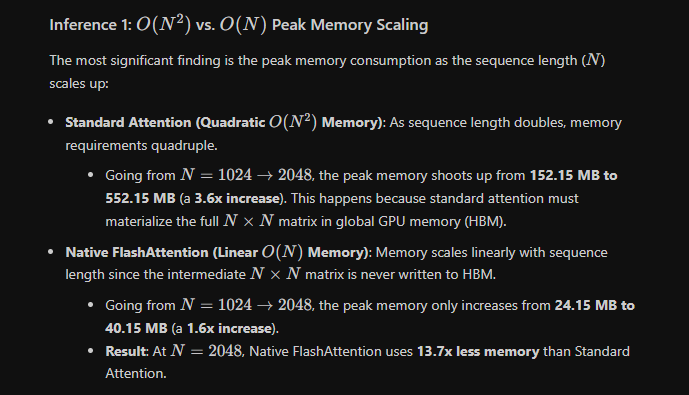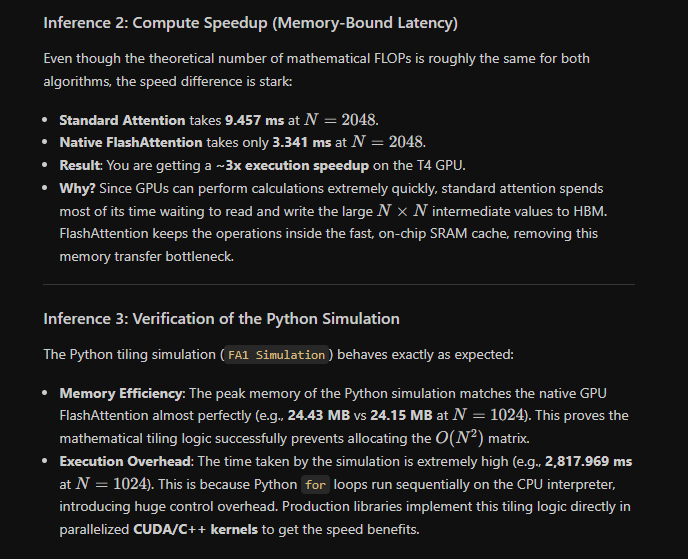